# Wisconsin Court Recidivism: Neighborhood-Aware Prediction Model

**Goal:** Build an open-source, socio-economically aware model that quantifies how
neighborhood-level census features (poverty, education, population density, etc.)
impact 180-day recidivism (`recid_180d`), and export artefacts for an interactive
dashboard.

## Notebook Structure
| # | Section | Purpose |
|---|---------|---------|
| 1 | Setup & Data Load | Install deps, load cleaned data |
| 2 | Feature Engineering | Create socio-economic composite indices |
| 3 | Exploratory Baseline | Neighborhood-level recidivism mapping |
| 4 | Modelling Pipeline | Logistic Regression, Random Forest, XGBoost, SHAP |
| 5 | Neighborhood Effect Quantification | Partial-dependence + SHAP grouping |
| 6 | Fairness Audit | Demographic parity & equalised odds |
| 7 | Dashboard Export |Streamlit |

> **Data note:** The notebook expects `wcld_model_ready.csv` produced by the
> accompanying EDA/cleaning notebook.  If that file is unavailable, synthetic
> data matching the schema is generated automatically so every cell still runs.


## 1  Setup & Data Load

In [1]:
# Install libraries
import subprocess, sys

def _install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["xgboost", "shap", "imbalanced-learn", "plotly"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        _install(pkg)

print("All dependencies available.")

All dependencies available.


In [2]:
import warnings, json, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    roc_curve, precision_recall_curve
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.impute import SimpleImputer
import xgboost as xgb
import shap
import scipy

from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (11, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded.")


Libraries loaded.


In [3]:
print(scipy.__version__)
print(shap.__version__)

1.15.3
0.48.0


In [4]:
# Load data 
DATA_PATH = 'C:\\Users\\miche\\Documents\\MSDS696_1\\wcld_model_ready.csv'

if not os.path.exists(DATA_PATH):
    print("\n" + "=" * 70)
    print("WARNING: Dataset file was not found.")
    print(f"Expected location: {DATA_PATH}")
    print("No synthetic/demo data will be created.")
    print("Please verify the file path and filename.")
    print("=" * 70 + "\n")
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

try:
    df = pd.read_csv(DATA_PATH, low_memory=False)

    if df.empty:
        raise ValueError("Dataset loaded successfully but contains no rows.")

    print(
        f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns "
        f"from {DATA_PATH}"
    )

except Exception as e:
    print("\n" + "=" * 70)
    print("WARNING: Dataset could not be loaded correctly.")
    print(f"File: {DATA_PATH}")
    print(f"Error: {e}")
    print("=" * 70 + "\n")
    raise

NEIGHBORHOOD_COLS = [
    "pct_black", "pct_hisp", "pct_male", "pct_rural", "pct_urban",
    "pct_college", "pct_somecollege", "pct_food_stamps", "pop_dens", "med_hhinc"
]

INDIVIDUAL_COLS = [
    "age_offense", "sex_encoded",
    "prior_felony", "prior_misdemeanor", "prior_criminal_traffic",
    "highest_severity", "violent_crime", "has_prior_jail",
    "max_hist_jail", "avg_hist_jail",
    "time_to_judgment",
    "flag_negative_time_to_judgment",
]

TARGET = "recid_180d"

NEIGHBORHOOD_COLS = [c for c in NEIGHBORHOOD_COLS if c in df.columns]
INDIVIDUAL_COLS = [c for c in INDIVIDUAL_COLS if c in df.columns]
ALL_FEATURES = INDIVIDUAL_COLS + NEIGHBORHOOD_COLS

df_model = df[df[TARGET].notna()].copy()

print(
    f"Model-ready rows: {df_model.shape[0]:,} | "
    f"Recidivism rate: {df_model[TARGET].mean():.2%}"
)

Loaded 1,357,746 rows × 61 columns from C:\Users\miche\Documents\MSDS696_1\wcld_model_ready.csv
Model-ready rows: 1,357,746 | Recidivism rate: 42.21%


## 2  Feature Engineering

### Socio-Economic Deprivation Index
A composite Z-score index combining neighborhood disadvantage signals:
`pct_food_stamps`, low `med_hhinc`, low `pct_college`.
Source: https://pmc.ncbi.nlm.nih.gov/articles/PMC6419301/

### Prior-Record Severity Score
Weighted sum of felony, misdemeanor, traffic priors.

### Urban-Rural Gradient
Continuous score from `pct_rural` and `pop_dens`.


In [5]:
# Socio-Economic Deprivation Index
# List of neighborhood variables that have indication of deprivation. 
sedi_components = [c for c in ["pct_food_stamps", "pct_black", "pct_hisp"] if c in df_model.columns]
# List of neighborhood variables associated with advantage.
sedi_neg = [c for c in ["med_hhinc", "pct_college"] if c in df_model.columns]

from sklearn.preprocessing import StandardScaler as _SS

# Fill missing values in deprivation variables and advantage variables using the median of each column 
# Standardize the values so all variables are on the same scale
_scaler = _SS()
_pos = _scaler.fit_transform(df_model[sedi_components].fillna(df_model[sedi_components].median()))
_neg = _scaler.fit_transform(df_model[sedi_neg].fillna(df_model[sedi_neg].median()))

# Create the socio-economic deprivation index, higher values indicate greater deprivation
# Index is average deprivation minus average advantage
df_model["SEDI"] = _pos.mean(axis=1) - _neg.mean(axis=1)
# Add the new variable to the list of neighborhood features
NEIGHBORHOOD_COLS.append("SEDI")

# Prior Record Score 
# Summarizes criminal history 
# Felonies receive the highest weight
# Misdemeanors receive a weight of 1
# Criminal traffic offenses receive a weight of 0.5
df_model["prior_score"] = (
    3 * df_model.get("prior_felony", 0).fillna(0)
    + df_model.get("prior_misdemeanor", 0).fillna(0)
    + 0.5 * df_model.get("prior_criminal_traffic", 0).fillna(0)
)
# Add the new variable to the list of individual features
INDIVIDUAL_COLS.append("prior_score")

# Urban Rural Gradient 
# Use the natural log of population density to reduce the impact of extreme values
# Subtract rural percentage so higher values represent more urban environments
if "pop_dens" in df_model.columns and "pct_rural" in df_model.columns:
    df_model["urban_gradient"] = (
        np.log1p(df_model["pop_dens"]) - df_model["pct_rural"]
    )
# Add the new feature to the neighborhood feature list
    NEIGHBORHOOD_COLS.append("urban_gradient")

# Refresh feature list
ALL_FEATURES = list(dict.fromkeys(INDIVIDUAL_COLS + NEIGHBORHOOD_COLS))
# Keep only features that actually exist in the dataset
ALL_FEATURES = [f for f in ALL_FEATURES if f in df_model.columns]

# Display the total number of features that will be used in modeling
print(f"Total features: {len(ALL_FEATURES)}")

# Display the number of available individual level features
print(f"  Individual: {len([f for f in INDIVIDUAL_COLS if f in df_model.columns])}")

# Display the number of available neighborhood level features
print(f"  Neighborhood: {len([f for f in NEIGHBORHOOD_COLS if f in df_model.columns])}")

# Show descriptive statistics for a subset of features
df_model[ALL_FEATURES[:5] + ["SEDI", "prior_score"]].describe().round(2)


Total features: 25
  Individual: 13
  Neighborhood: 12


,age_offense,sex_encoded,prior_felony,prior_misdemeanor,prior_criminal_traffic,SEDI,prior_score
count,1357746.00,1357746.00,1357746.00,1357746.00,1357746.00,1357746.00,1357746.00
mean,30.82,0.79,1.00,1.45,0.73,0.00,4.81
std,10.86,0.40,1.69,2.27,1.51,1.46,6.49
min,14.00,0.00,0.00,0.00,0.00,-11.17,0.00
25%,22.00,1.00,0.00,0.00,0.00,-0.80,0.00
50%,28.00,1.00,0.00,1.00,0.00,-0.16,3.00
75%,38.00,1.00,1.00,2.00,1.00,0.62,7.00
max,94.00,1.00,22.00,60.00,27.00,5.82,102.00


## 3  Exploratory Neighborhood Analysis

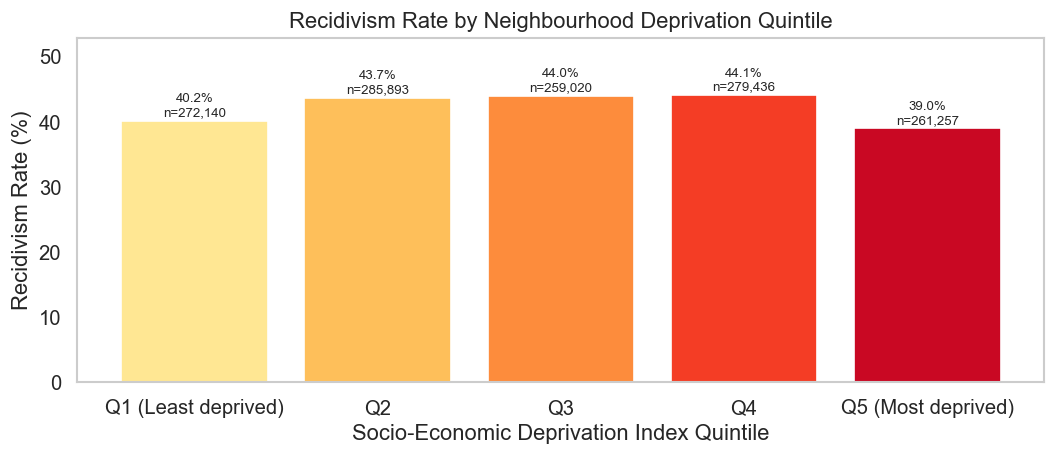

      SEDI_quintile  recid_rate      n
Q1 (Least deprived)    0.401705 272140
                 Q2    0.436723 285893
                 Q3    0.439688 259020
                 Q4    0.440734 279436
 Q5 (Most deprived)    0.390076 261257


In [6]:
# Socio-Economic Deprivation Index quintiles vs recidivism rate 
# Create five equally sized groups based on Socio-Economic Deprivation Index values
# Q1 represents the least deprived neighborhoods, Q5 represents the most deprived neighborhoods
df_model["SEDI_quintile"] = pd.qcut(df_model["SEDI"], q=5,
                                     labels=["Q1 (Least deprived)", "Q2", "Q3", "Q4", "Q5 (Most deprived)"])

# Calculate the average recidivism rate 
# Calculate the number of observations winthin each Socio-Economic Deprivation Index quintile
# The mean of a binary target variable represents the proportion of individuals who recidivated
sedi_recid = (
    df_model.groupby("SEDI_quintile")[TARGET]
    .agg(recid_rate="mean", n="count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))

# Bar chart showing recidivism rates for each deprivation quintile
bars = ax.bar(
    sedi_recid["SEDI_quintile"].astype(str),
    sedi_recid["recid_rate"] * 100,
    color=sns.color_palette("YlOrRd", 5),
    edgecolor="white"
)
for bar, (_, row) in zip(bars, sedi_recid.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{row.recid_rate*100:.1f}%\nn={row.n:,}",
            ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Recidivism Rate (%)")
ax.set_xlabel("Socio-Economic Deprivation Index Quintile")
ax.set_title("Recidivism Rate by Neighbourhood Deprivation Quintile")
ax.grid(False)
ax.set_ylim(0, sedi_recid["recid_rate"].max() * 120)
plt.tight_layout()
plt.show()
print(sedi_recid.to_string(index=False))


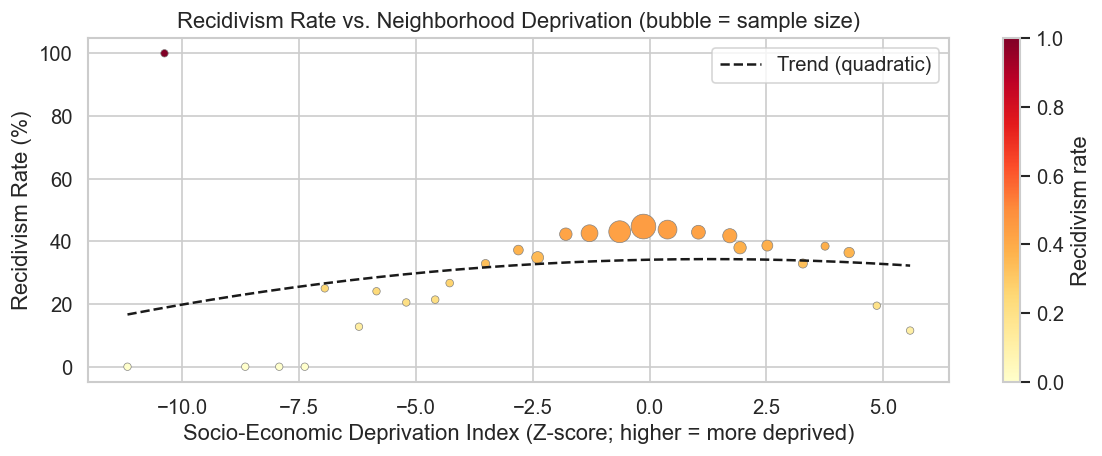

In [7]:
# Scatter: Socio-Economic Deprivation Index vs recidivism (binned)
# Divide the continuous Socio-Economic Deprivation Index values into 30 intervals
# For easier examination of how recidivism changes across different levels of neighborhood deprivation
df_model["SEDI_bin"] = pd.cut(df_model["SEDI"], bins=30)

# Calculate summary statistics for each Socio-Economic Deprivation Index interval
# recid_rate: average recidivism rate within the interval
# n: number of observations within the interval
# SEDI_mid: median Socio-Economic Deprivation Index value within the interval (x-coordinate)
bin_stats = (
    df_model.groupby("SEDI_bin", observed=True)
    .agg(recid_rate=(TARGET, "mean"), n=(TARGET, "count"), SEDI_mid=("SEDI", "median"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))

# Bubble chart of relationship between neighborhood deprivation and recidivism
# Bubble size: number of observations in the bin
# Bubble color: recidivism rate
sc = ax.scatter(bin_stats["SEDI_mid"], bin_stats["recid_rate"] * 100,
                s=bin_stats["n"] / bin_stats["n"].max() * 200 + 20,
                c=bin_stats["recid_rate"], cmap="YlOrRd", edgecolors="grey", linewidths=0.4)

# Fit a quadratic trend line to summarize the overall relationship between deprivation and recidivism
z = np.polyfit(bin_stats["SEDI_mid"].dropna(),
               (bin_stats["recid_rate"] * 100).loc[bin_stats["SEDI_mid"].notna()], 2)
# Convert the fitted coefficients into a polynomial function
p = np.poly1d(z)
# Create a sequence of x values spanning the observed Socio-Economic Deprivation Index range
xs = np.linspace(bin_stats["SEDI_mid"].min(), bin_stats["SEDI_mid"].max(), 200)
# Plot the fitted quadratic trend line
ax.plot(xs, p(xs), "k--", linewidth=1.5, label="Trend (quadratic)")
plt.colorbar(sc, ax=ax, label="Recidivism rate")
ax.set_xlabel("Socio-Economic Deprivation Index (Z-score; higher = more deprived)")
ax.set_ylabel("Recidivism Rate (%)")
ax.set_title("Recidivism Rate vs. Neighborhood Deprivation (bubble = sample size)")
ax.legend()
plt.tight_layout()
plt.show()


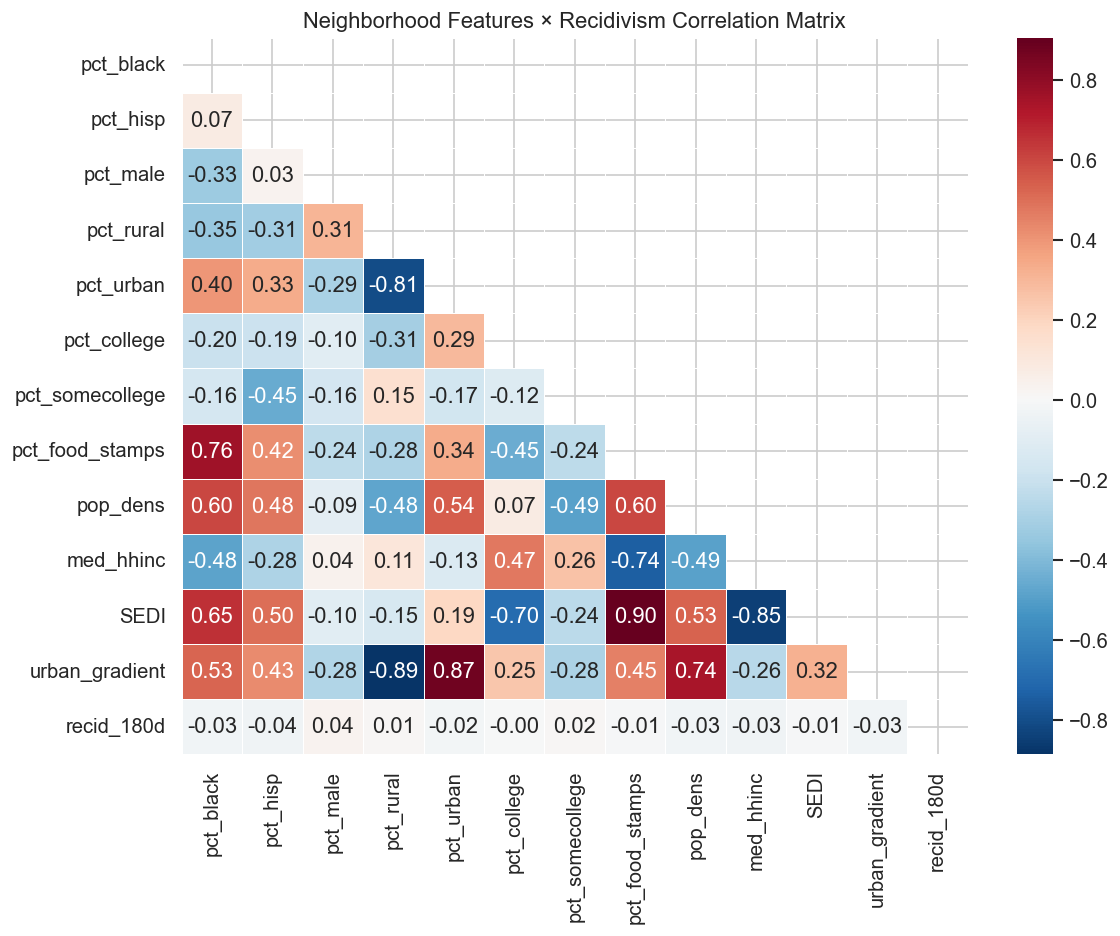

In [8]:
# Neighborhood feature correlation heatmap with target
nc_target = [c for c in NEIGHBORHOOD_COLS if c in df_model.columns] + [TARGET]
# Calculate the Pearson correlation matrix
corr = df_model[nc_target].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.4, ax=ax)
ax.set_title("Neighborhood Features × Recidivism Correlation Matrix")
plt.tight_layout()
plt.show()

In [9]:
# Create summary table of feature correlations with target
corr_summary = (
    corr[[TARGET]]
    .drop(index=TARGET)               
    .rename(columns={TARGET: "Correlation"})
    .assign(
        Abs_Correlation=lambda x: x["Correlation"].abs(),
        Direction=lambda x: np.where(
            x["Correlation"] >= 0,
            "Positive",
            "Negative"
        )
    )
    .sort_values("Abs_Correlation", ascending=False)
)

print("\nNeighborhood Feature Correlations with Target")
display(corr_summary.round(3))


Neighborhood Feature Correlations with Target


,Correlation,Abs_Correlation,Direction
pct_hisp,-0.039,0.039,Negative
pct_male,0.037,0.037,Positive
med_hhinc,-0.033,0.033,Negative
pct_black,-0.032,0.032,Negative
pop_dens,-0.032,0.032,Negative
urban_gradient,-0.028,0.028,Negative
pct_urban,-0.021,0.021,Negative
pct_somecollege,0.016,0.016,Positive
pct_rural,0.014,0.014,Positive
pct_food_stamps,-0.010,0.010,Negative


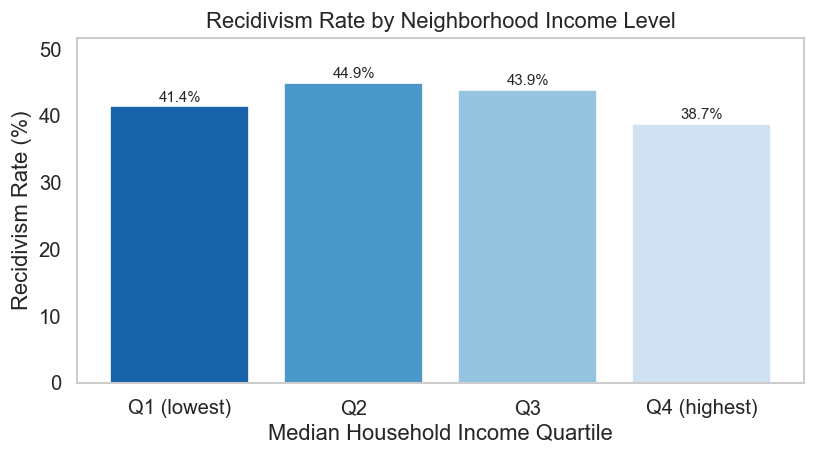

In [10]:
# Median household income vs recidivism by Socio-Economic Deprivation Index quartile
# Divide neighborhoods into four equally sized income groups
# Q1 contains the lowest income neighborhoods, Q4 contains the highest income neighborhoods
if "med_hhinc" in df_model.columns:
    df_model["hhinc_q"] = pd.qcut(df_model["med_hhinc"], q=4,
                                   labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
    
# Calculate the average recidivism rate within each neighborhood income group
# Mean of the binary target variable represents the proportion of individuals who recidivated
    hhinc_recid = (
        df_model.groupby("hhinc_q")[TARGET]
        .mean().reset_index()
        .rename(columns={TARGET: "recid_rate"})
    )
    fig, ax = plt.subplots(figsize=(7, 4))
# Bar chart of recidivism rate for each median household income quartile
    bars = ax.bar(
        hhinc_recid["hhinc_q"].astype(str),
        hhinc_recid["recid_rate"] * 100,
        color=sns.color_palette("Blues_r", 4),
        edgecolor="white"
    )
    for bar, rate in zip(bars, hhinc_recid["recid_rate"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{rate * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )
    ax.set_ylabel("Recidivism Rate (%)")
    ax.set_xlabel("Median Household Income Quartile")
    ax.grid(False)
    ax.set_title("Recidivism Rate by Neighborhood Income Level")
    ax.set_ylim(0, hhinc_recid["recid_rate"].max() * 100 * 1.15)

    plt.tight_layout()
    plt.show()


## 4  Modelling Pipeline

Three models trained and compared:
1. Logistic Regression : interpretable baseline with L2 regularisation
2. Random Forest : ensemble with permutation importance
3. XGBoost : gradient boosting

Class imbalance handled with SMOTE on the training fold.
Evaluation uses five-fold stratified cross-validation (AUC-ROC, AUC-PR).


In [11]:
# Create a list of feature names that exist in the dataset
feat_cols = [f for f in ALL_FEATURES if f in df_model.columns]

# Create feature matrix containing only the selected predictor variables
X = df_model[feat_cols].copy()

# Remove columns that contain only missing values
X = X.dropna(axis=1, how='all')

# Convert all columns to numeric data types
X = X.apply(pd.to_numeric, errors='coerce')

# Create an imputer replaces missing values with the median value of each column
imputer = SimpleImputer(strategy="median")

# Apply the imputer to fill missing values in the feature matrix
X_imp = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

In [12]:
# Split the dataset into training and testing sets
# X_imp: predictor variables, y: target variable
y = df_model[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"Train recidivism rate: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")

Train: 1,086,196  |  Test: 271,550
Train recidivism rate: 42.21%  |  Test: 42.21%


In [13]:
# SMOTE on training set to create new training dataset where the minority class has been oversampled
# to improve class balance and test set is not modified to ensure fair evaluation.
sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f"After SMOTE – train size: {len(X_train_res):,} | "
      f"class balance: {y_train_res.mean():.2%}")


After SMOTE – train size: 1,255,384 | class balance: 50.00%


In [15]:
# Standardize feature values
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc = scaler.transform(X_test)

# Define final models 
models = {
    "Logistic Regression": LogisticRegression(
        C=0.01,
        solver="liblinear",
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        verbosity=0
    )
}

results = {}

print("Training models...\n")

for name, clf in models.items():

    # Logistic Regression uses scaled features
    if name == "Logistic Regression":
        clf.fit(X_train_sc, y_train_res)
        y_prob = clf.predict_proba(X_test_sc)[:, 1]
    else:
        clf.fit(X_train_res, y_train_res)
        y_prob = clf.predict_proba(X_test)[:, 1]

    auc_roc = roc_auc_score(y_test, y_prob)
    auc_pr = average_precision_score(y_test, y_prob)

    results[name] = {
        "model": clf,
        "y_prob": y_prob,
        "AUC-ROC": auc_roc,
        "AUC-PR": auc_pr
    }

    print(f"{name:<25} AUC-ROC={auc_roc:.4f}  AUC-PR={auc_pr:.4f}")


Training models...

Logistic Regression       AUC-ROC=0.6839  AUC-PR=0.5963
Random Forest             AUC-ROC=0.6954  AUC-PR=0.6096
XGBoost                   AUC-ROC=0.7043  AUC-PR=0.6247


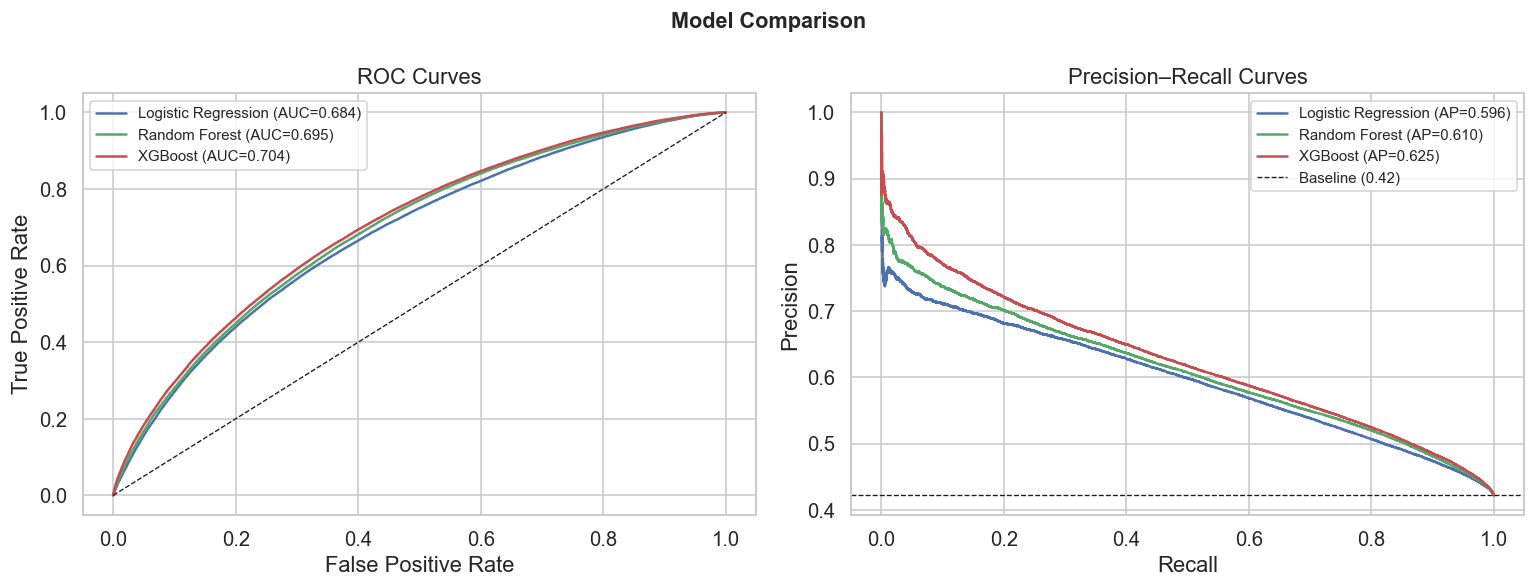

In [16]:
# OC and Precision-Recall curves 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#4C72B0", "#55A868", "#C44E52"]

for (name, res), color in zip(results.items(), colors):
    # ROC
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['AUC-ROC']:.3f})", color=color)
    # PR
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    axes[1].plot(rec, prec, label=f"{name} (AP={res['AUC-PR']:.3f})", color=color)

axes[0].plot([0,1],[0,1],"k--", linewidth=0.8)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves"); axes[0].legend(fontsize=9)

# Calculate baseline precision
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color="k", linestyle="--", linewidth=0.8,
                label=f"Baseline ({baseline_pr:.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall Curves"); axes[1].legend(fontsize=9)

plt.suptitle("Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Best model: XGBoost  (AUC-ROC=0.7043)

               precision    recall  f1-score   support

No Recidivism       0.69      0.74      0.71    156923
   Recidivism       0.60      0.55      0.57    114627

     accuracy                           0.66    271550
    macro avg       0.65      0.64      0.64    271550
 weighted avg       0.65      0.66      0.65    271550



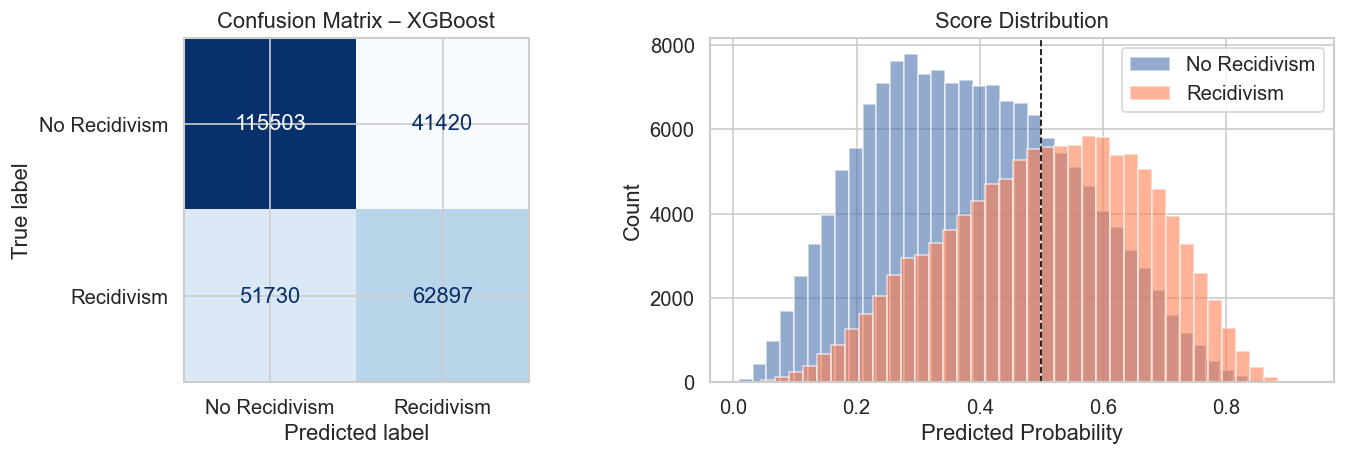

In [17]:
# Classification report
# Identify the model with the highest AUC ROC score
best_name  = max(results, key=lambda k: results[k]["AUC-ROC"])
best_model = results[best_name]["model"]
best_prob  = results[best_name]["y_prob"]

# Convert predicted probabilities into class predictions, threshold of 0.5 is used
best_pred  = (best_prob >= 0.5).astype(int)

print(f"Best model: {best_name}  (AUC-ROC={results[best_name]['AUC-ROC']:.4f})")
print()
print(classification_report(y_test, best_pred, target_names=["No Recidivism", "Recidivism"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Display a confusion matrix to compare actual outcomes to predicted outcomes
ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred,
    display_labels=["No Recidivism", "Recidivism"],
    colorbar=False, ax=axes[0], cmap="Blues"
)
axes[0].set_title(f"Confusion Matrix – {best_name}")

# Probability calibration
# Plot probability distributions for predicted scores
# Histogram shows probabilities for cases with no recidivism
axes[1].hist(best_prob[y_test==0], bins=40, alpha=0.6, label="No Recidivism", color="#4C72B0")
# Histogram shows probabilities for cases with recidivism
axes[1].hist(best_prob[y_test==1], bins=40, alpha=0.6, label="Recidivism",    color="coral")
# Vertical reference line at the 0.5 decision threshold
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Predicted Probability"); axes[1].set_ylabel("Count")
axes[1].set_title("Score Distribution"); axes[1].legend()
plt.tight_layout()
plt.show()


## 5  Neighborhood Effect Quantification

### Methods
- SHAP values : unified framework for feature attribution
- Partial Dependence Plots : marginal effect of each neighborhood feature
- Neighborhood feature importance ranking : SHAP vs Permutation comparison


In [22]:
# SHAP values
# Create a SHAP explainer object for the XGBoost model to explain how each feature contributes to model predictions
xgb_model = results["XGBoost"]["model"]
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

print(shap_values.shape)

(271550, 25)


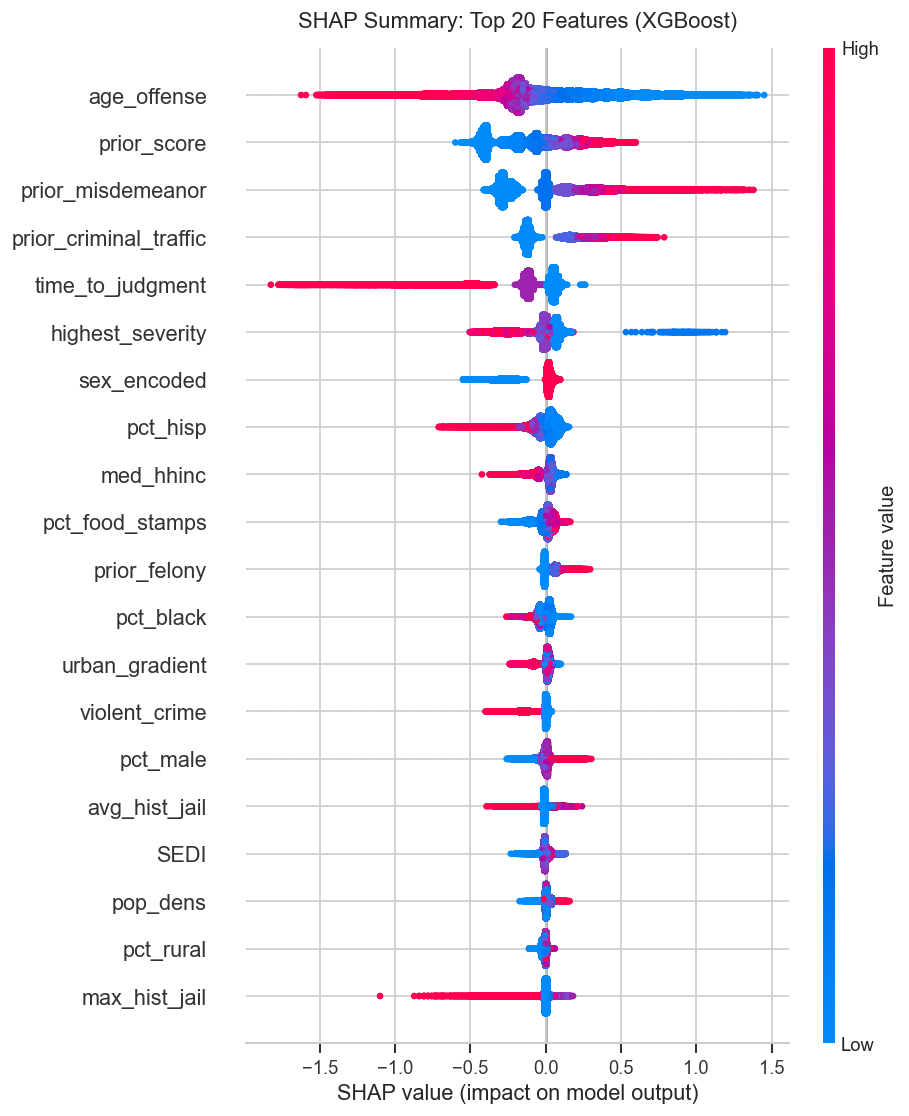

In [23]:
# Global SHAP summary 
# Shows how each feature contributes to the XGBoost model predictions
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=feat_cols,
                  max_display=20, show=False, plot_type="dot")
plt.title("SHAP Summary: Top 20 Features (XGBoost)", pad=12)
plt.tight_layout()
plt.show()


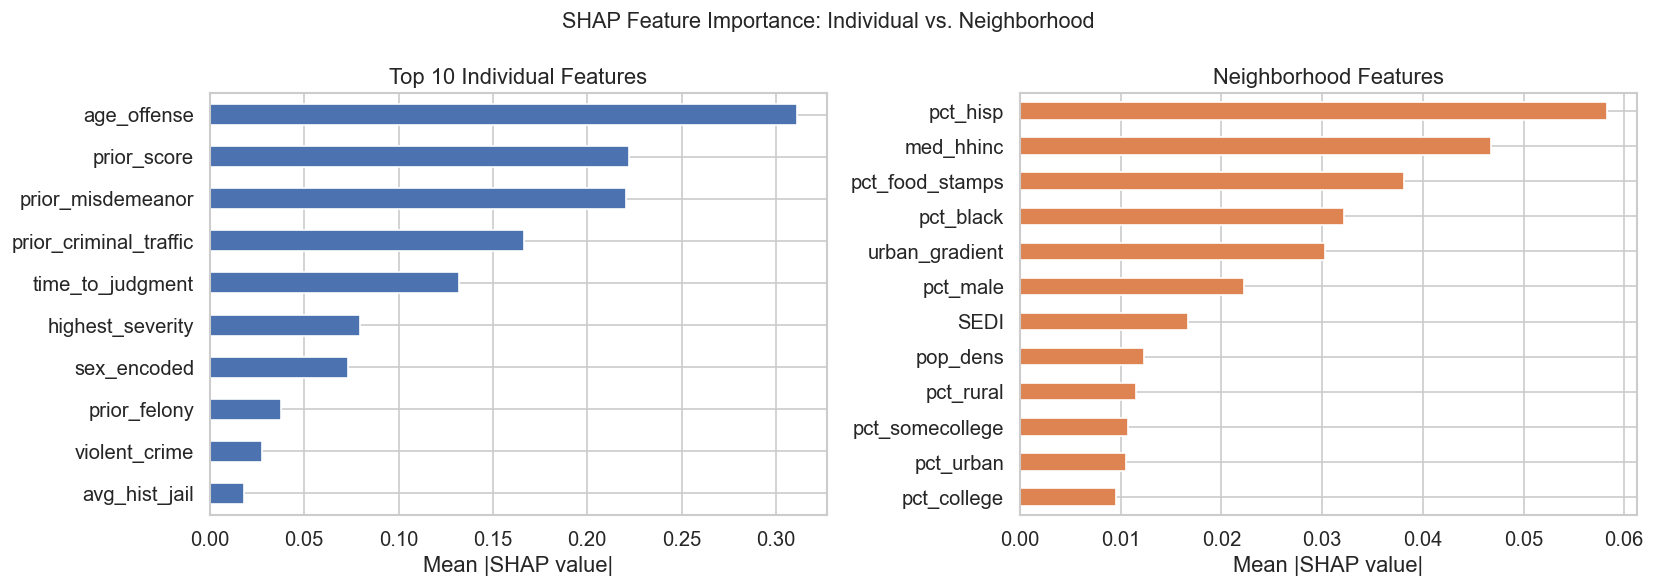


Neighborhood features account for 18.7% of total model explanation
Individual features account for 81.3% of total model explanation


In [25]:
# Neighborhood vs Individual feature SHAP comparison
# Create sets of feature names for easy grouping
nc_set = set(NEIGHBORHOOD_COLS)
ic_set = set(INDIVIDUAL_COLS)

# Compute mean absolute SHAP value for each feature
mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=feat_cols)

# Filter SHAP values to include only neighborhood-related features
shap_neighborhood = mean_abs_shap[[f for f in feat_cols if f in nc_set]].sort_values(ascending=False)

# Filter SHAP values to include only individual-related features
shap_individual = mean_abs_shap[[f for f in feat_cols if f in ic_set]].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot shows top individual features
# Right plot shows neighborhood features
for ax, series, title, color in zip(
    axes,
    [shap_individual.head(10), shap_neighborhood],
    ["Top 10 Individual Features", "Neighborhood Features"],
    ["#4C72B0", "#DD8452"]
):
    series.sort_values().plot(kind="barh", ax=ax, color=color, edgecolor="white")
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(title)

plt.suptitle("SHAP Feature Importance: Individual vs. Neighborhood", fontsize=13)
plt.tight_layout()
plt.show()

# Compute total contribution of all features to model explanation
total_shap = mean_abs_shap.sum()
# Compute percentage contribution from neighborhood features
neighborhood_pct = mean_abs_shap[[f for f in feat_cols if f in nc_set]].sum() / total_shap * 100
# Compute percentage contribution from individual features
individual_pct = mean_abs_shap[[f for f in feat_cols if f in ic_set]].sum() / total_shap * 100
# Percentage contribution of neighborhood features
print(f"\nNeighborhood features account for {neighborhood_pct:.1f}% of total model explanation")
# Percentage contribution of individual features
print(f"Individual features account for {individual_pct:.1f}% of total model explanation")


In [29]:
shap_array_1 = shap_values.values

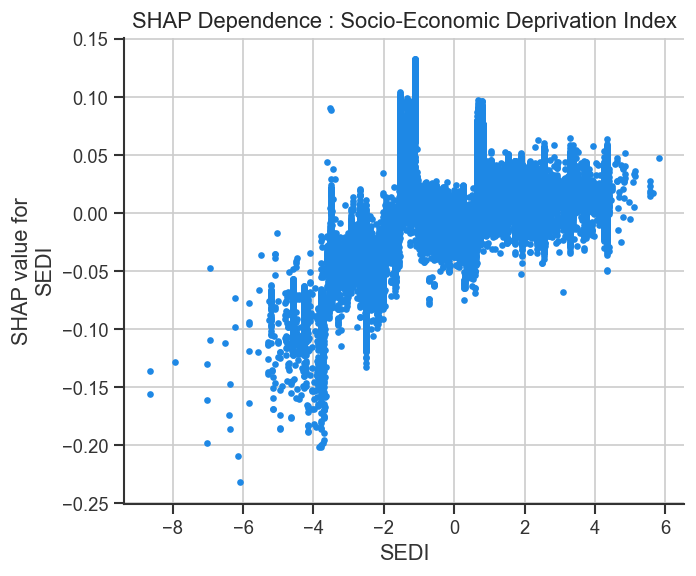

In [31]:
# SHAP dependence: Socio-Economic Deprivation Index
if "SEDI" in feat_cols:
    sedi_idx = feat_cols.index("SEDI")

    shap.dependence_plot(
        "SEDI",
        shap_array_1,
        X_test,
        feature_names=feat_cols,
        interaction_index=None,
        show=False
    )

    plt.title("SHAP Dependence : Socio-Economic Deprivation Index")
    plt.tight_layout()
    plt.show()


## 6  Fairness Audit

We measure three group-fairness criteria across racial groups (where available):

| Metric | Definition |
|--------|-----------|
| **Demographic Parity** | Difference in positive prediction rates across groups |
| **Equalised Odds (TPR)** | Difference in True Positive Rate across groups |
| **Equalised Odds (FPR)** | Difference in False Positive Rate across groups |
| **AUC by group** | Discrimination ability within each subgroup |


In [32]:
# Attach predictions to test set 
X_test_df = X_test.copy()
X_test_df["y_true"] = y_test
X_test_df["y_prob_xgb"] = results["XGBoost"]["y_prob"]
X_test_df["y_pred_xgb"] = (X_test_df["y_prob_xgb"] >= 0.5).astype(int)

# Attach race / year from original df_model using index alignment
for col in ["race", "year"]:
    if col in df_model.columns:
        X_test_df[col] = df_model.loc[X_test.index, col].values


,n,Recidivism Rate,Predicted Positive Rate,TPR (Recall),FPR,AUC-ROC
Race/Ethnicity,,,,,,
African American,58470,0.464,0.417,0.573,0.282,0.707
American Indian or Alaskan Native,11897,0.558,0.569,0.680,0.429,0.683
Asian or Pacific Islander,2546,0.397,0.429,0.634,0.295,0.722
Caucasian,179717,0.402,0.367,0.534,0.253,0.704
Hispanic,18920,0.396,0.327,0.470,0.232,0.671


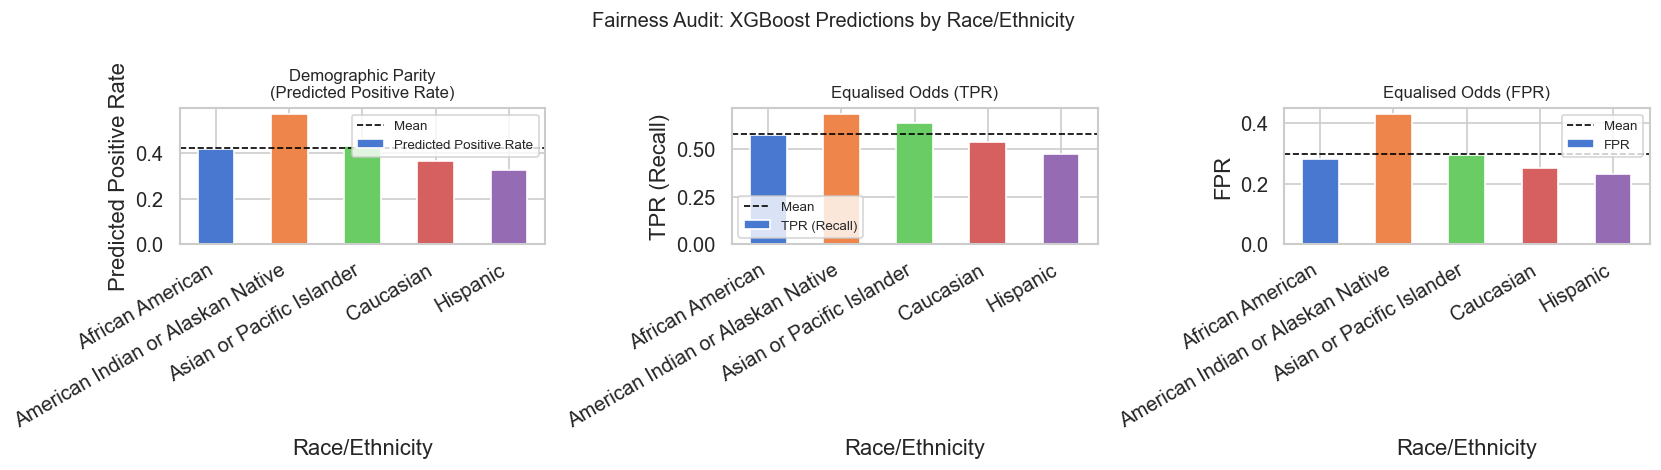

In [33]:
# Fairness table by race 
if "race" in X_test_df.columns:
    rows = []
    for group, gdf in X_test_df.groupby("race"):
        if gdf["y_true"].nunique() < 2:
            continue
        tp = ((gdf["y_pred_xgb"]==1) & (gdf["y_true"]==1)).sum()
        fp = ((gdf["y_pred_xgb"]==1) & (gdf["y_true"]==0)).sum()
        fn = ((gdf["y_pred_xgb"]==0) & (gdf["y_true"]==1)).sum()
        tn = ((gdf["y_pred_xgb"]==0) & (gdf["y_true"]==0)).sum()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        ppr = gdf["y_pred_xgb"].mean()
        auc = roc_auc_score(gdf["y_true"], gdf["y_prob_xgb"])
        rows.append({"Race/Ethnicity": group, "n": len(gdf),
                     "Recidivism Rate": gdf["y_true"].mean(),
                     "Predicted Positive Rate": ppr,
                     "TPR (Recall)": tpr,
                     "FPR": fpr,
                     "AUC-ROC": auc})
    
    fairness_df = pd.DataFrame(rows).set_index("Race/Ethnicity")
    display(fairness_df.round(3))

    # Visual
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, col, title in zip(
        axes,
        ["Predicted Positive Rate", "TPR (Recall)", "FPR"],
        ["Demographic Parity\n(Predicted Positive Rate)",
         "Equalised Odds (TPR)", "Equalised Odds (FPR)"]
    ):
        fairness_df[col].plot(kind="bar", ax=ax,
                              color=sns.color_palette("muted", len(fairness_df)),
                              edgecolor="white")
        ax.set_title(title, fontsize=10)
        ax.set_ylabel(col)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
        ax.axhline(fairness_df[col].mean(), color="black", linestyle="--",
                   linewidth=1, label="Mean")
        ax.legend(fontsize=8)
    plt.suptitle("Fairness Audit: XGBoost Predictions by Race/Ethnicity", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Race column not in test set; skipping fairness audit.")


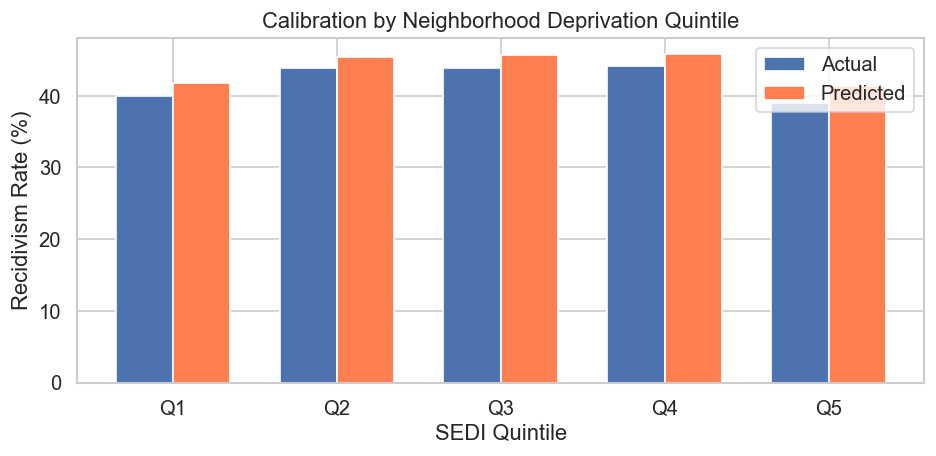

,SEDI_quintile,Mean Predicted,Mean Actual,n
0,Q1,0.418,0.400,54578.0
1,Q2,0.454,0.439,57188.0
2,Q3,0.457,0.439,51743.0
3,Q4,0.458,0.441,55917.0
4,Q5,0.413,0.390,52124.0


In [34]:
# Calibration by Socio-Economic Deprivation Index quintile 
X_test_df["SEDI_quintile"] = pd.qcut(
    X_test_df["SEDI"] if "SEDI" in X_test_df.columns else df_model.loc[X_test.index, "SEDI"],
    q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
)

calib = (
    X_test_df.groupby("SEDI_quintile")
    .apply(lambda g: pd.Series({
        "Mean Predicted": g["y_prob_xgb"].mean(),
        "Mean Actual": g["y_true"].mean(),
        "n": len(g)
    }))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(calib))
w = 0.35
ax.bar(x - w/2, calib["Mean Actual"] * 100,  w, label="Actual", color="#4C72B0", edgecolor="white")
ax.bar(x + w/2, calib["Mean Predicted"] * 100, w, label="Predicted", color="coral", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(calib["SEDI_quintile"].astype(str))
ax.set_xlabel("SEDI Quintile")
ax.set_ylabel("Recidivism Rate (%)")
ax.set_title("Calibration by Neighborhood Deprivation Quintile")
ax.legend()
plt.tight_layout()
plt.show()
display(calib.round(3))


## 7  Dashboard Export Artefacts

All files are written to `./dashboard_data/` and are ready for:
- **Streamlit** – `pd.read_csv` + `px.bar` / `px.scatter`


| File | Contents |
|------|----------|
| `model_scores.csv` | Individual test-set predictions + features |
| `feature_importance.csv` | SHAP mean absolute values per feature |
| `fairness_metrics.csv` | Fairness metrics by race/ethnicity |
| `sedi_recid.csv` | Recidivism rate by SEDI quintile |
| `model_metadata.json` | AUC scores, feature list, threshold |


In [38]:
output_dir = "dashboard_data"
os.makedirs(output_dir, exist_ok=True)

print("exporting dashboard artifacts")

# Save test dataset for dashboard scoring and inspection
X_test_df.to_csv(f"{output_dir}/model_scores.csv", index=False)
print("done --> model_scores.csv")

# Compute shap feature importance efficiently using numpy array
shap_array = shap_values.values if hasattr(shap_values, "values") else np.array(shap_values)

fi_df = pd.DataFrame({
    "feature": feat_cols,
    "shap_mean_abs": np.abs(shap_array).mean(axis=0),
    "category": [
        "neighborhood" if f in nc_set else "individual"
        for f in feat_cols
    ]
}).sort_values("shap_mean_abs", ascending=False).reset_index(drop=True)

fi_df.to_csv(f"{output_dir}/feature_importance.csv", index=False)
print("done --> feature_importance.csv")

# Export fairness metrics if available
if "fairness_df" in globals():
    fairness_df.reset_index().to_csv(f"{output_dir}/fairness_metrics.csv", index=False)
    print("done --> fairness_metrics.csv")

# Export grouped outcome data
sedi_recid.to_csv(f"{output_dir}/sedi_recid.csv", index=False)
print("done --> sedi_recid.csv")

# Export model metadata only (no pdp dependency)
metadata = {
    "best_model": best_name,
    "auc_roc": {k: float(round(v["AUC-ROC"], 4)) for k, v in results.items()},
    "auc_pr": {k: float(round(v["AUC-PR"], 4)) for k, v in results.items()},
    "threshold": 0.5,
    "n_features": int(len(feat_cols)),
    "features": feat_cols,
    "neighborhood_features": [f for f in feat_cols if f in nc_set],
    "individual_features": [f for f in feat_cols if f in ic_set],
    "neighborhood_shap_pct": float(round(neighborhood_pct, 1)),
    "individual_shap_pct": float(round(individual_pct, 1)),
    "target": TARGET,
    "train_size": int(len(X_train)),
    "test_size": int(len(X_test))
}

with open(f"{output_dir}/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("done --> model_metadata.json")

print("all dashboard artifacts saved")

exporting dashboard artifacts
done --> model_scores.csv
done --> feature_importance.csv
done --> fairness_metrics.csv
done --> sedi_recid.csv
done --> model_metadata.json
all dashboard artifacts saved
